In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [2]:
csv_path = r"C:\Users\ADMIN\Downloads\mediapipe_landmarks_ASL_shuffled.csv"

df = pd.read_csv(csv_path)

X = df.drop("label", axis=1).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 29548
Test size: 7388


In [3]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", __import__("sklearn").svm.SVC(kernel='rbf', gamma='scale'))
])

svm_model.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test))

print("SVM Train Accuracy:", svm_train_acc)
print("SVM Test Accuracy:", svm_test_acc)


SVM Train Accuracy: 0.9877487478001895
SVM Test Accuracy: 0.9860584731997835


In [3]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# SVM with probability=True for confidence scores
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', gamma='scale', probability=True))
])

# Train model
svm_model.fit(X_train, y_train)

# Accuracies
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test))

print("SVM Train Accuracy:", svm_train_acc)
print("SVM Test Accuracy:", svm_test_acc)


SVM Train Accuracy: 0.9877487478001895
SVM Test Accuracy: 0.9860584731997835


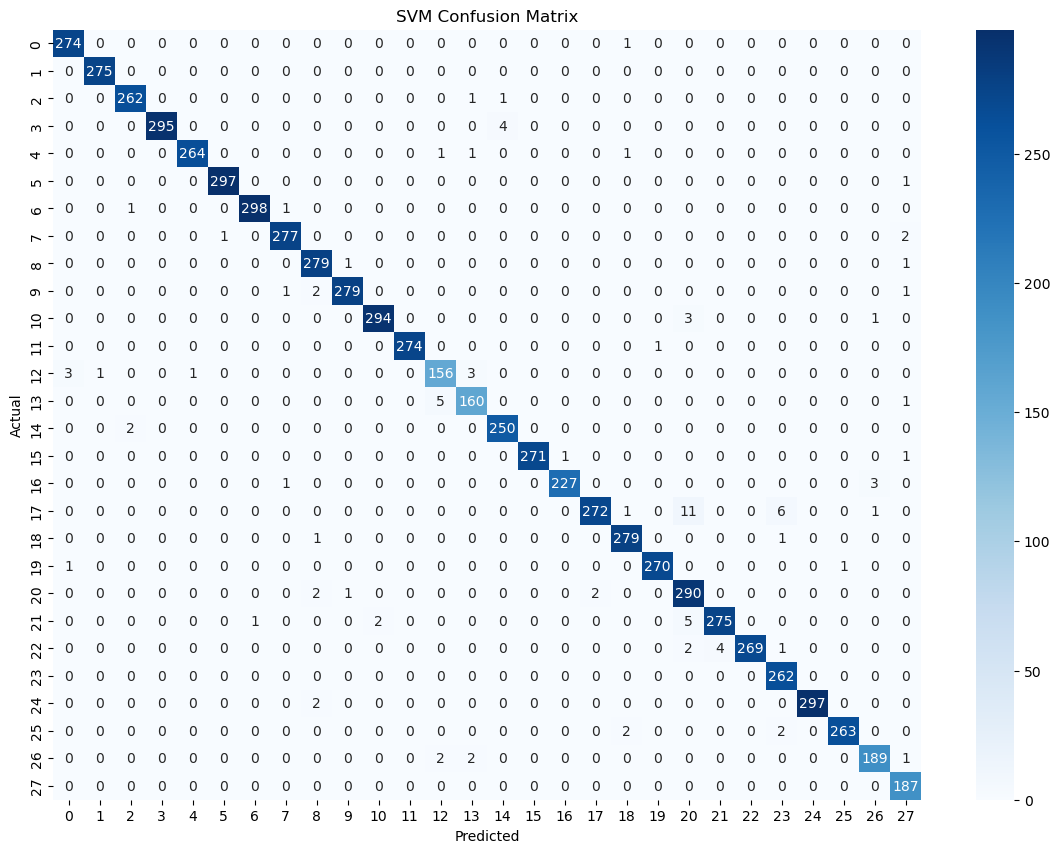

In [4]:
svm_preds = svm_model.predict(X_test)
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [5]:
pickle.dump(svm_model, open("svm_mediapipe.pkl_1", "wb"))
print("Saved SVM model as svm_mediapipe.pkl_1")

Saved SVM model as svm_mediapipe.pkl_1


In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))
knn_test_acc = accuracy_score(y_test, knn_model.predict(X_test))

print("KNN Train Accuracy:", knn_train_acc)
print("KNN Test Accuracy:", knn_test_acc)


KNN Train Accuracy: 0.9857181535129281
KNN Test Accuracy: 0.9787493232268544


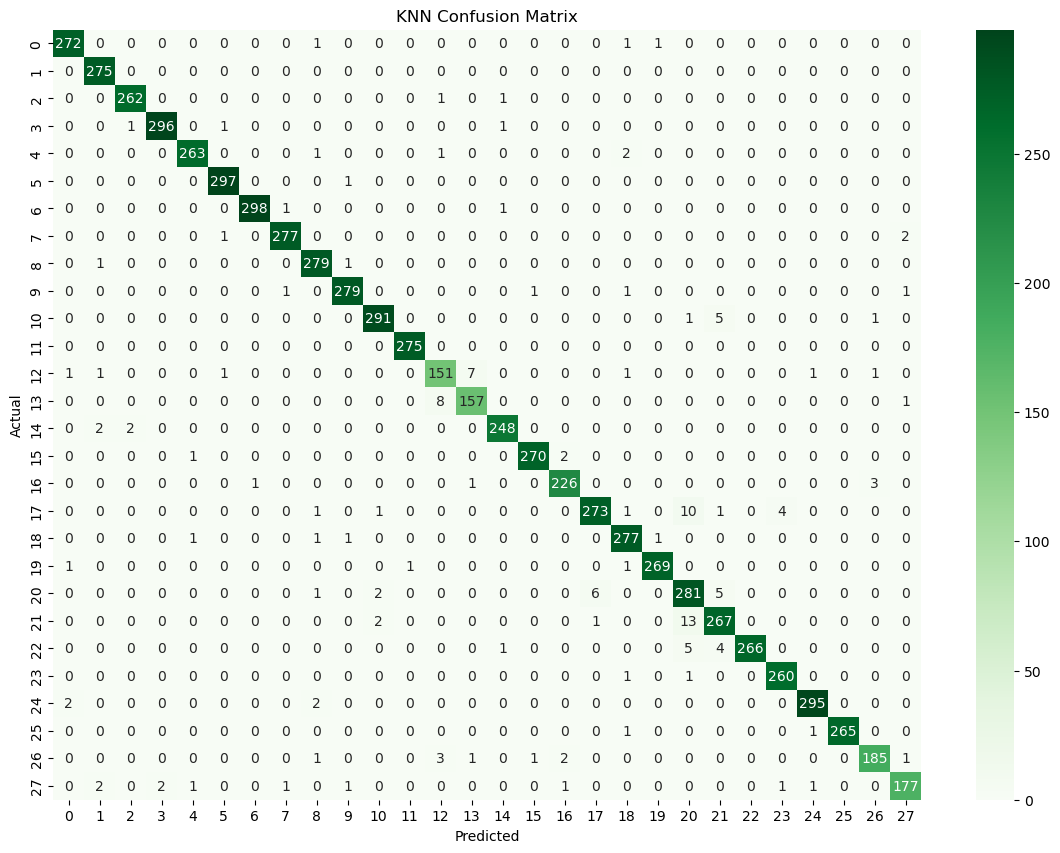

In [10]:
knn_preds = knn_model.predict(X_test)
cm_knn = confusion_matrix(y_test, knn_preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
pickle.dump(knn_model, open("knn_mediapipe.pkl", "wb"))
print("Saved KNN model as knn_mediapipe.pkl")

Saved KNN model as knn_mediapipe.pkl


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print("RF Train Accuracy:", rf_train_acc)
print("RF Test Accuracy:", rf_test_acc)


RF Train Accuracy: 1.0
RF Test Accuracy: 0.9847049269085003


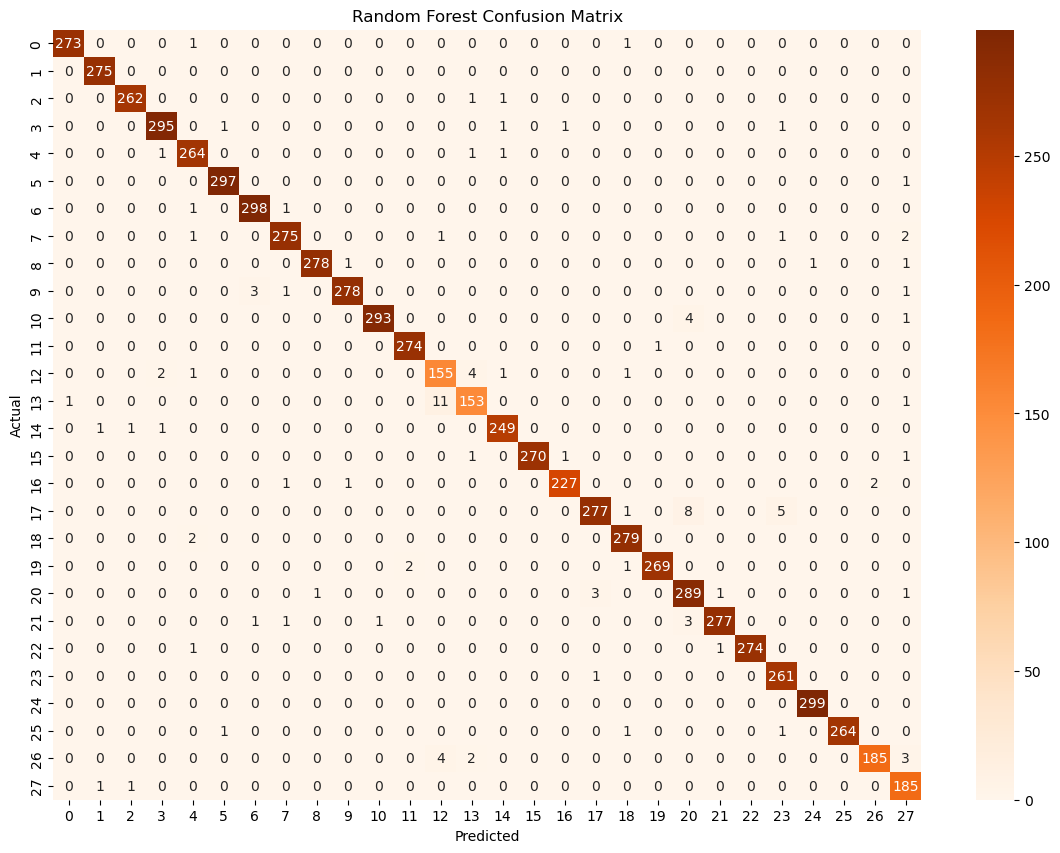

In [13]:
rf_preds = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
pickle.dump(rf_model, open("rf_mediapipe.pkl", "wb"))
print("Saved RF model as rf_mediapipe.pkl")

Saved RF model as rf_mediapipe.pkl
